Features (X):


,Chins,Situps,Jumps
0,5.0,162.0,60.0
1,2.0,110.0,60.0
2,12.0,101.0,101.0
3,12.0,105.0,37.0
4,13.0,155.0,58.0


Targets (y):


,Weight,Waist,Pulse
0,191.0,36.0,50.0
1,189.0,37.0,52.0
2,193.0,38.0,58.0
3,162.0,35.0,62.0
4,189.0,35.0,46.0



Missing values in X:
Chins     0
Situps    0
Jumps     0
dtype: int64

Missing values in y:
Weight    0
Waist     0
Pulse     0
dtype: int64

Descriptive statistics for X:


,Chins,Situps,Jumps
count,20.000000,20.000000,20.00000
mean,9.450000,145.550000,70.30000
std,5.286278,62.566575,51.27747
min,1.000000,50.000000,25.00000
25%,4.750000,101.000000,39.50000
50%,11.500000,122.500000,54.00000
75%,13.250000,210.000000,85.25000
max,17.000000,251.000000,250.00000



Descriptive statistics for y:


,Weight,Waist,Pulse
count,20.000000,20.000000,20.000000
mean,178.600000,35.400000,56.100000
std,24.690505,3.201973,7.210373
min,138.000000,31.000000,46.000000
25%,160.750000,33.000000,51.500000
50%,176.000000,35.000000,55.000000
75%,191.500000,37.000000,60.500000
max,247.000000,46.000000,74.000000


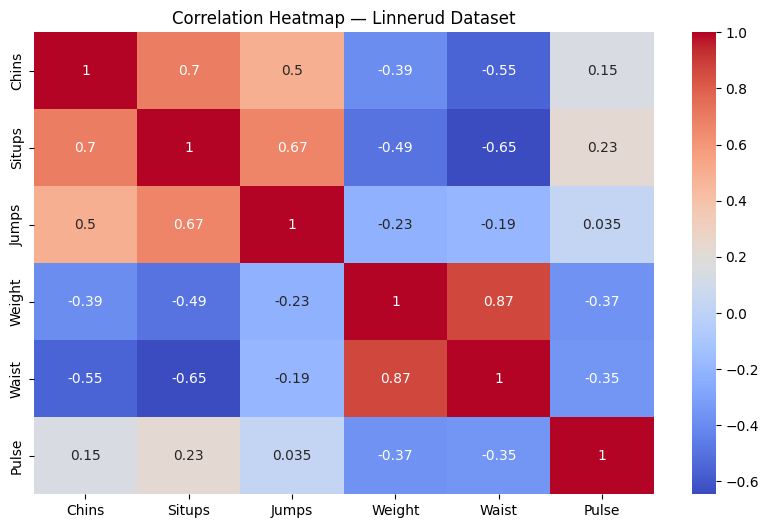

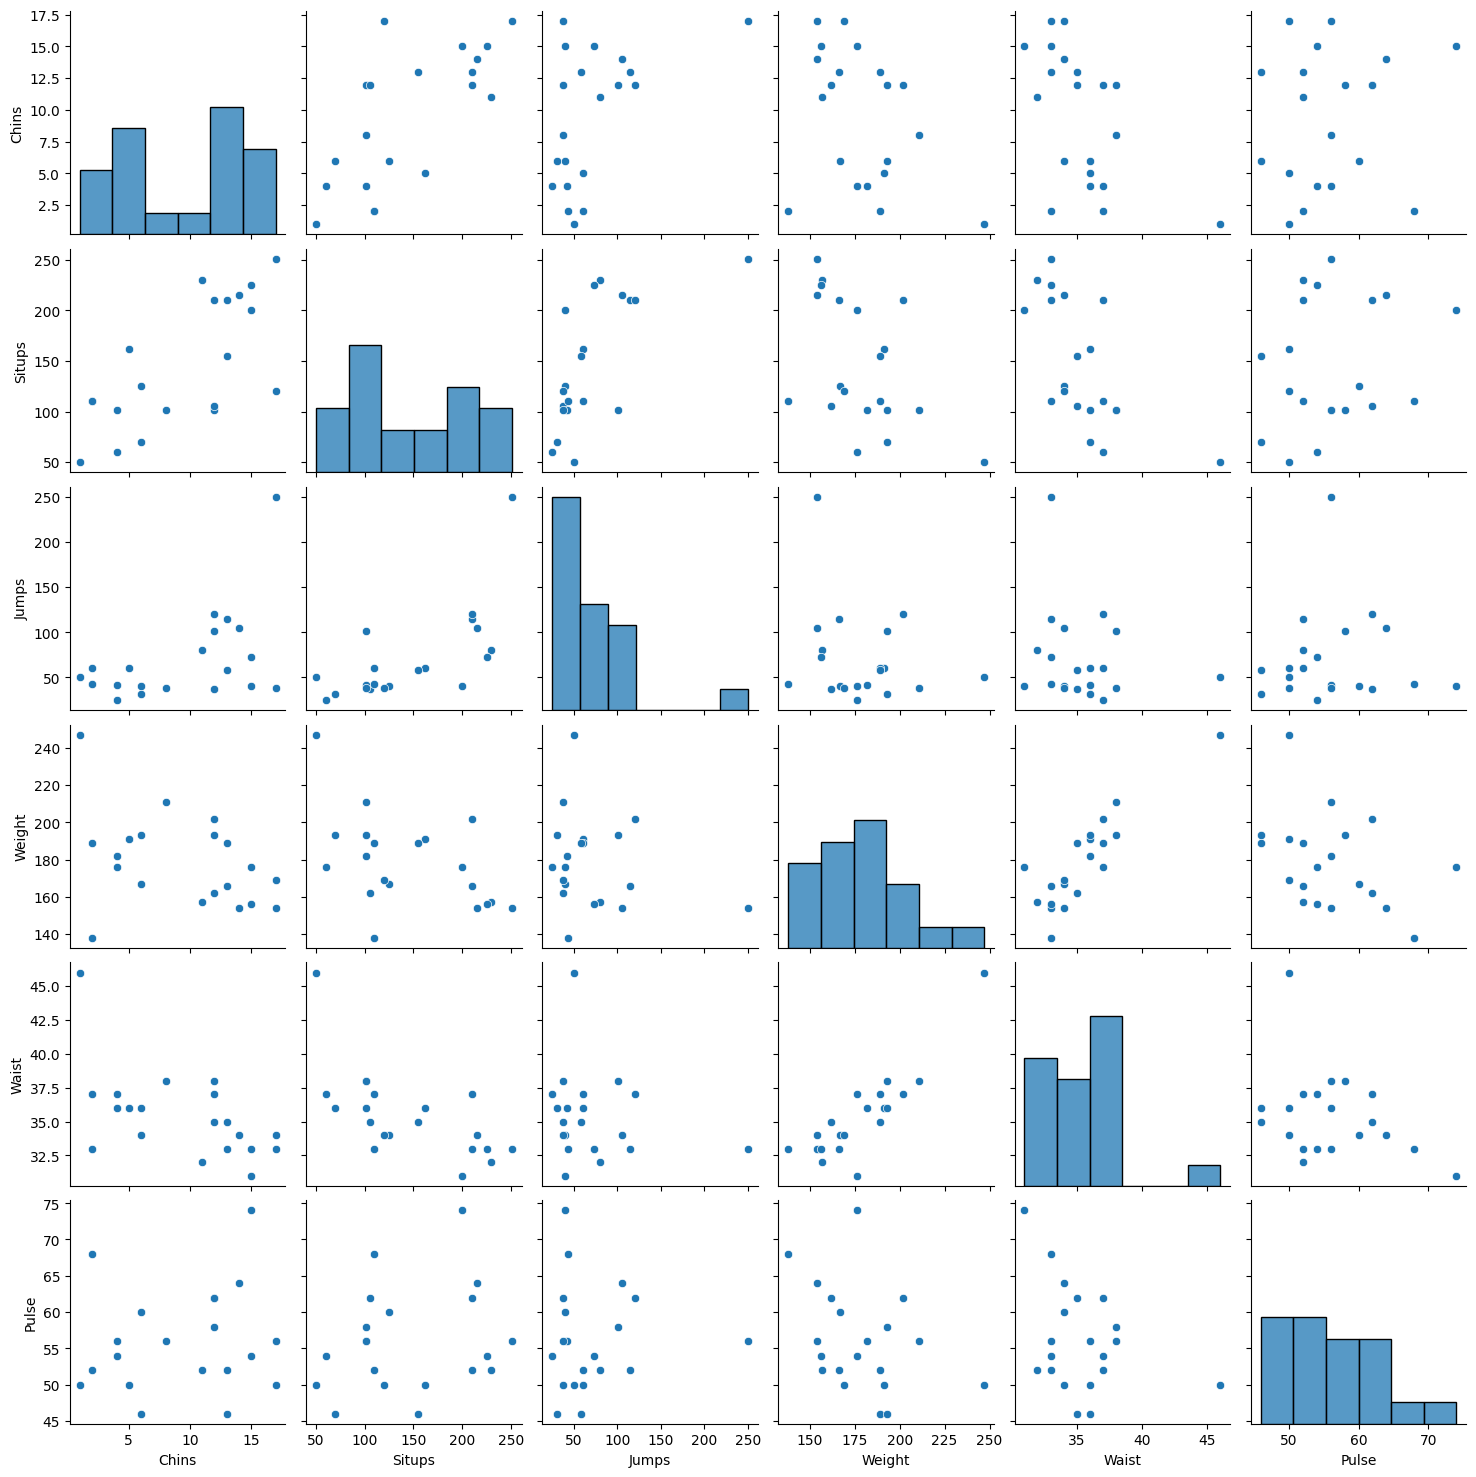


Model Evaluation:
Weight: R² = -1.243, RMSE = 25.115
Waist: R² = -0.076, RMSE = 2.138
Pulse: R² = -2.732, RMSE = 9.062


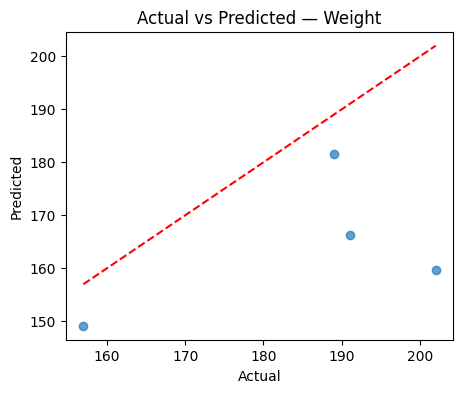

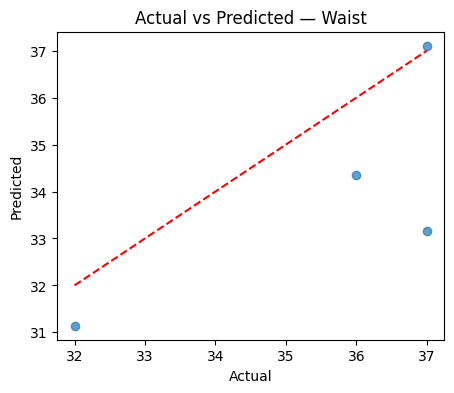

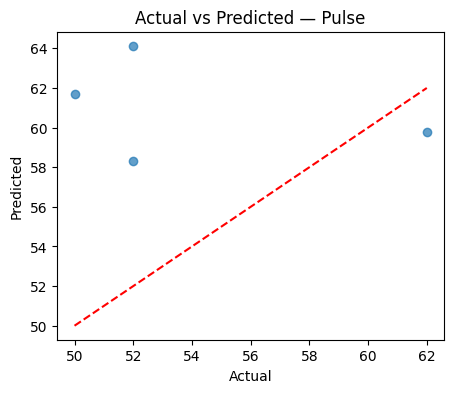


Sample input:


,Chins,Situps,Jumps
0,5.0,162.0,60.0



Predicted physiological values:
[[166.29944554  34.34931272  61.69268724]]

Lasso Regression Evaluation:
Weight: R² = -1.176, RMSE = 24.735
Waist: R² = -0.005, RMSE = 2.067
Pulse: R² = -2.300, RMSE = 8.521


In [1]:
# ============================================================
# LINNERUD DATASET — FULL WORKFLOW
# EDA → Linear Regression → Evaluation → Visualization → Lasso
# ============================================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_linnerud
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# ------------------------------------------------------------
# 1. LOAD THE LINNERUD DATASET
# ------------------------------------------------------------

lin = load_linnerud()

# Convert to DataFrames
X = pd.DataFrame(lin.data, columns=lin.feature_names)       # Exercise data
y = pd.DataFrame(lin.target, columns=lin.target_names)      # Physiological data

print("Features (X):")
display(X.head())

print("Targets (y):")
display(y.head())

# ------------------------------------------------------------
# 2. TRAIN–TEST SPLIT (80% train, 20% test)
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ------------------------------------------------------------
# 3. EXPLORATORY DATA ANALYSIS (EDA)
# ------------------------------------------------------------

print("\nMissing values in X:")
print(X.isna().sum())

print("\nMissing values in y:")
print(y.isna().sum())

print("\nDescriptive statistics for X:")
display(X.describe())

print("\nDescriptive statistics for y:")
display(y.describe())

# Correlation heatmap (features + targets)
plt.figure(figsize=(10, 6))
sns.heatmap(pd.concat([X, y], axis=1).corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap — Linnerud Dataset")
plt.show()

# Pairplot (features vs targets)
sns.pairplot(pd.concat([X, y], axis=1))
plt.show()

# ------------------------------------------------------------
# 4. BUILD LINEAR REGRESSION MODEL
# ------------------------------------------------------------

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

# Predictions
y_pred = lin_reg.predict(X_test)

# ------------------------------------------------------------
# 5. EVALUATE MODEL (R² and RMSE for each target)
# ------------------------------------------------------------

print("\nModel Evaluation:")

for i, col in enumerate(y.columns):
    r2 = r2_score(y_test[col], y_pred[:, i])
    rmse = np.sqrt(mean_squared_error(y_test[col], y_pred[:, i]))
    print(f"{col}: R² = {r2:.3f}, RMSE = {rmse:.3f}")

# ------------------------------------------------------------
# 6. VISUALIZE ACTUAL vs PREDICTED
# ------------------------------------------------------------

for i, col in enumerate(y.columns):
    plt.figure(figsize=(5, 4))
    plt.scatter(y_test[col], y_pred[:, i], alpha=0.7)
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(f"Actual vs Predicted — {col}")
    plt.plot([y_test[col].min(), y_test[col].max()],
             [y_test[col].min(), y_test[col].max()], "r--")
    plt.show()

# ------------------------------------------------------------
# 7. MAKE PREDICTIONS ON NEW DATA
# ------------------------------------------------------------

sample = X_test.iloc[0:1]   # take one test sample
print("\nSample input:")
display(sample)

sample_pred = lin_reg.predict(sample)
print("\nPredicted physiological values:")
print(sample_pred)

# ------------------------------------------------------------
# 8. IMPROVE MODEL — NORMALIZATION + LASSO REGRESSION
# ------------------------------------------------------------

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split again using scaled data
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Lasso Regression
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_s, y_train_s)

y_pred_lasso = lasso.predict(X_test_s)

print("\nLasso Regression Evaluation:")

for i, col in enumerate(y.columns):
    r2 = r2_score(y_test_s[col], y_pred_lasso[:, i])
    rmse = np.sqrt(mean_squared_error(y_test_s[col], y_pred_lasso[:, i]))
    print(f"{col}: R² = {r2:.3f}, RMSE = {rmse:.3f}")